In [11]:
import pandas as pd
import xml.etree.ElementTree as ET
from pathlib import Path

from src.helpers import parse_edges
import src.inputs.config as cfg
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
import xml.etree.ElementTree as ET

tree = ET.parse("/home/marta/tesi-5t/DTBaldissera/vm-file/project/scripts/output/marouter-workdir/MA_no_TLS_AM/marouter_output_extended.rou.xml")
root = tree.getroot()

count = 0
for veh in root.findall("vehicle") + root.findall("trip"):
    route_el = veh.find("route")
    count += 1
print(f"Veicoli con destinazione MAROUTER {count}")

Veicoli con destinazione MAROUTER 27587


In [30]:
vehroutes_am  = Path("/home/marta/tesi-5t/DTBaldissera/vm-file/project/scripts/output/simulation-out/out_MA_no_TLS/VehTraces_marouter_DAY.xml")

tree = ET.parse(vehroutes_am)
root = tree.getroot()

data_list = []

for veh in root.findall("vehicle"):
    veh_data = {
        "id": veh.get("id"), 
        "depart": float(veh.get("depart")) if veh.get("depart") else None,
        "departLane": veh.get("departLane"),
        "departSpeed": float(veh.get("departSpeed")) if veh.get("departSpeed") else None,
        "fromTaz": veh.get("fromTaz"),
        "toTaz": veh.get("toTaz"),
        "speedFactor": float(veh.get("speedFactor")) if veh.get("speedFactor") else None, # Corretto refuso 'fpeedFactor'
        "arrival": float(veh.get("arrival")) if veh.get("arrival") else None,
        "routeLength": float(veh.get("routeLength")) if veh.get("routeLength") else None,
    }
    
    route = veh.find("route")
    if route is not None:
        veh_data["route_edges"] = route.get("edges")
        veh_data["route_exitTimes"] = route.get("exitTimes") if route.get("exitTimes") else None
    
    param = veh.find("param")
    if param is not None:
        veh_data["param_key"] = param.get("key")
        veh_data["param_value"] = float(param.get("value"))
        
    data_list.append(veh_data)

df_res = pd.DataFrame(data_list)
df_res

,id,depart,departLane,departSpeed,fromTaz,toTaz,speedFactor,arrival,routeLength,route_edges,route_exitTimes,param_key,param_value
0,342,34.0,0,13.5455,10007,10012,0.9752,216.0,2158.92,111596716 677704593#1 677704593#2 677704593#3 ...,41.00 49.00 49.00 50.00 51.00 57.00 65.00 71.0...,weight,10007.0
1,541,38.0,0,21.0477,10012,10007,1.0827,92.0,896.36,1307721869#6 1307721869#7 1307721869#8 1307721...,39.00 40.00 43.00 48.00 55.00 62.00 63.00 63.0...,weight,10012.0
2,1186,47.0,2,11.1430,635,10002,1.2004,63.0,190.11,1305812827#0 1305812827#1 36357295 397427448#0...,48.00 49.00 51.00 53.00 54.00 60.00 63.00,weight,635.0
3,741,50.0,1,3.4690,10017,10001,1.0458,166.0,1553.76,1311112378#1 1311112378#2 913296515#0 91329651...,51.00 51.00 53.00 58.00 61.00 62.00 66.00 67.0...,weight,10017.0
4,913,52.0,0,9.2097,573,10009,1.0777,189.0,533.17,1311144281#16 1311144281#17 1311144281#18 1305...,53.00 55.00 57.00 59.00 69.00 71.00 73.00 74.0...,weight,573.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
179873,141559,86393.0,0,2.8809,10007,10013,1.1410,NaN,19.55,154986384#4 122368886#3 122368886#4 122368886#...,-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -...,weight,10007.0
179874,168226,86394.0,0,4.7307,10005,632,0.9684,NaN,6.01,122368886#0 259248595 -323979861 243127219#3 2...,-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -...,weight,10005.0
179875,148469,86396.0,2,6.3204,575,10012,0.8747,NaN,5.00,1307179611#2 1307179611#3 659342821 1307179610...,86397.00 -1 -1 -1 -1 -1 -1 -1 -1,weight,575.0
179876,141108,86396.0,0,3.0409,10007,10012,0.9291,NaN,9.62,154986384#4 122368886#3 122368886#4 122368886#...,-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -...,weight,10007.0


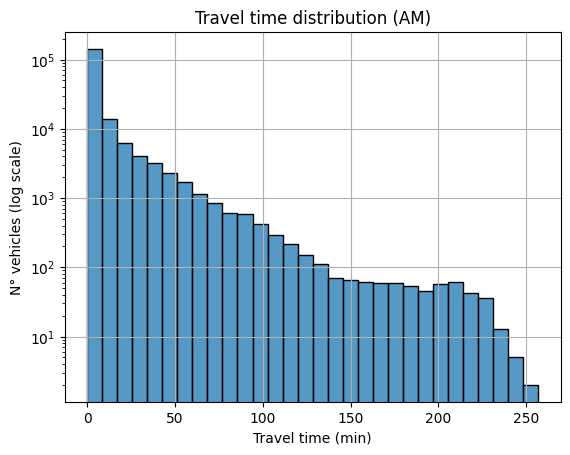

In [39]:
df_res["duration"] = (df_res['arrival'] - df_res['depart']) / 60
sns.histplot(df_res["duration"], bins=30)
plt.title('Travel time distribution (AM)')
plt.xlabel('Travel time (min)')
plt.ylabel("N° vehicles (log scale)")
plt.yscale(value="log")
plt.grid(True)

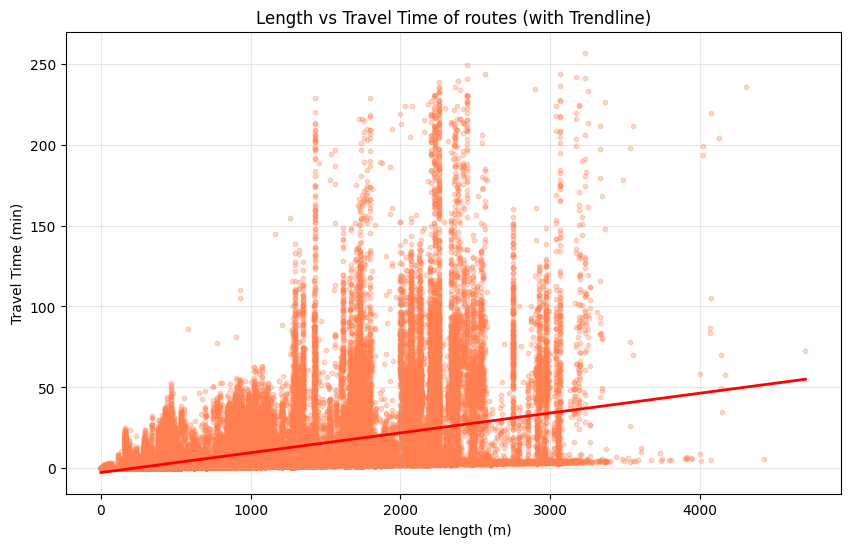

In [32]:
plt.figure(figsize=(10, 6))

# alpha=0.1 rende i punti trasparenti per vedere la densità
# robust=True o lowess=True aiutano a non farsi influenzare troppo dagli outlier in alto
sns.regplot(
    data=df_res, 
    x='routeLength', 
    y='duration', 
    color='coral',
    scatter_kws={'alpha': 0.3, 's': 10},  # punti piccoli e trasparenti
    line_kws={'color': 'red', 'linewidth': 2}  # linea di regressione ben visibile
)

plt.title('Length vs Travel Time of routes (with Trendline)')
plt.xlabel('Route length (m)')
plt.ylabel('Travel Time (min)')
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_2596/2907979046.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_edges.values, y=top_edges.index, palette='viridis')


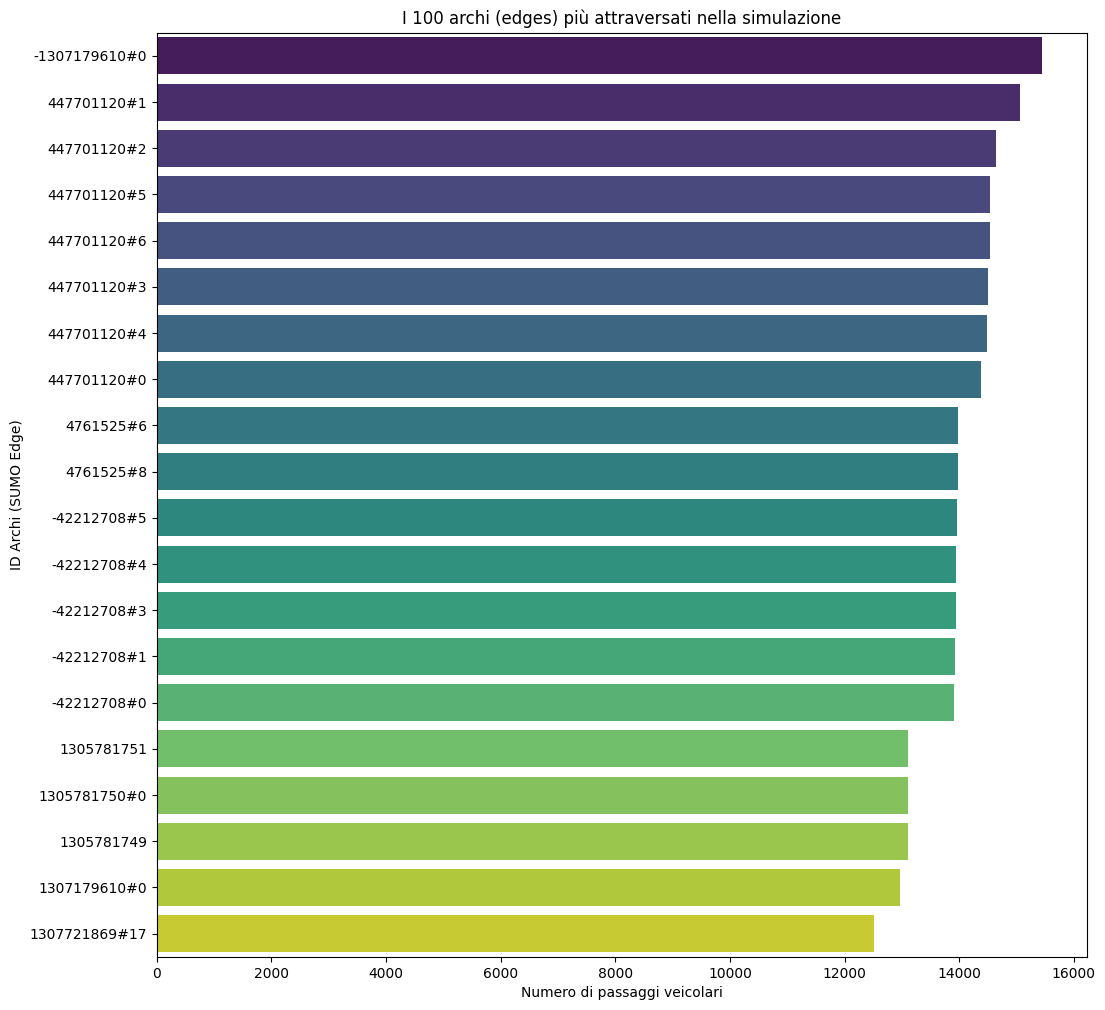

In [40]:
all_edges = df_res['route_edges'].str.split(' ').explode()
top_edges = all_edges.value_counts().head(20)

plt.figure(figsize=(12, 12))
sns.barplot(x=top_edges.values, y=top_edges.index, palette='viridis')
plt.title('I 30 archi (edges) più attraversati nella simulazione')
plt.xlabel('Numero di passaggi veicolari')
plt.ylabel('ID Archi (SUMO Edge)')
plt.show()

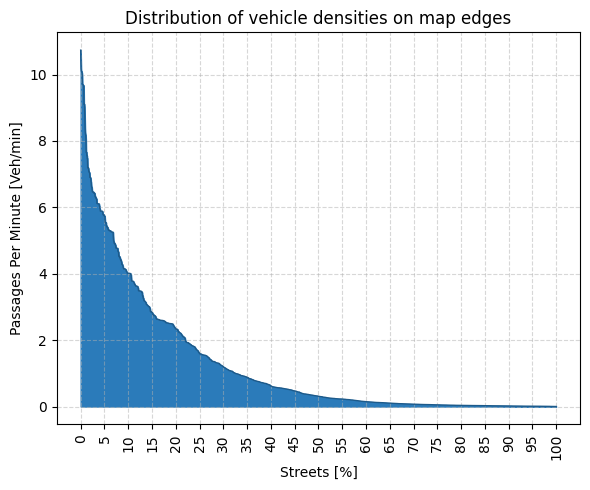

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calcoliamo la durata della simulazione in minuti
# Prendiamo l'ultimo arrivo e il primo inserimento
durata_minuti = (df_res['arrival'].max() - df_res['depart'].min()) / 60.0

# 2. Contiamo i passaggi totali su ogni edge (strada)
edge_counts = df_res['route_edges'].str.split(' ').explode().value_counts()

# Se vuoi includere anche le strade della mappa con ZERO passaggi, dovresti caricarle dal .net.xml.
# Altrimenti questo grafico mostrerà la distribuzione solo sulle strade effettivamente usate.

# 3. Trasformiamo in Passaggi Per Minuto (Veh/min) e ordiniamo in modo decrescente
passages_per_min = (edge_counts / durata_minuti).sort_values(ascending=False).values

# 4. Creiamo l'asse X come percentuale delle strade (da 0 a 100%)
num_streets = len(passages_per_min)
streets_percentage = np.linspace(0, 100, num_streets)

# 5. Plot del grafico (a)
plt.figure(figsize=(6, 5))
plt.fill_between(streets_percentage, passages_per_min, color='#2b7bba')
plt.plot(streets_percentage, passages_per_min, color='#1d5a8a', linewidth=1)

plt.title("Distribution of vehicle densities on map edges")
plt.xlabel("Streets [%]")
plt.ylabel("Passages Per Minute [Veh/min]")
plt.xlim(-5, 105)
plt.xticks(ticks=np.arange(0, 101, 5), rotation=90)
plt.grid(True, alpha=0.5, linestyle='--')
plt.tight_layout()
plt.show()

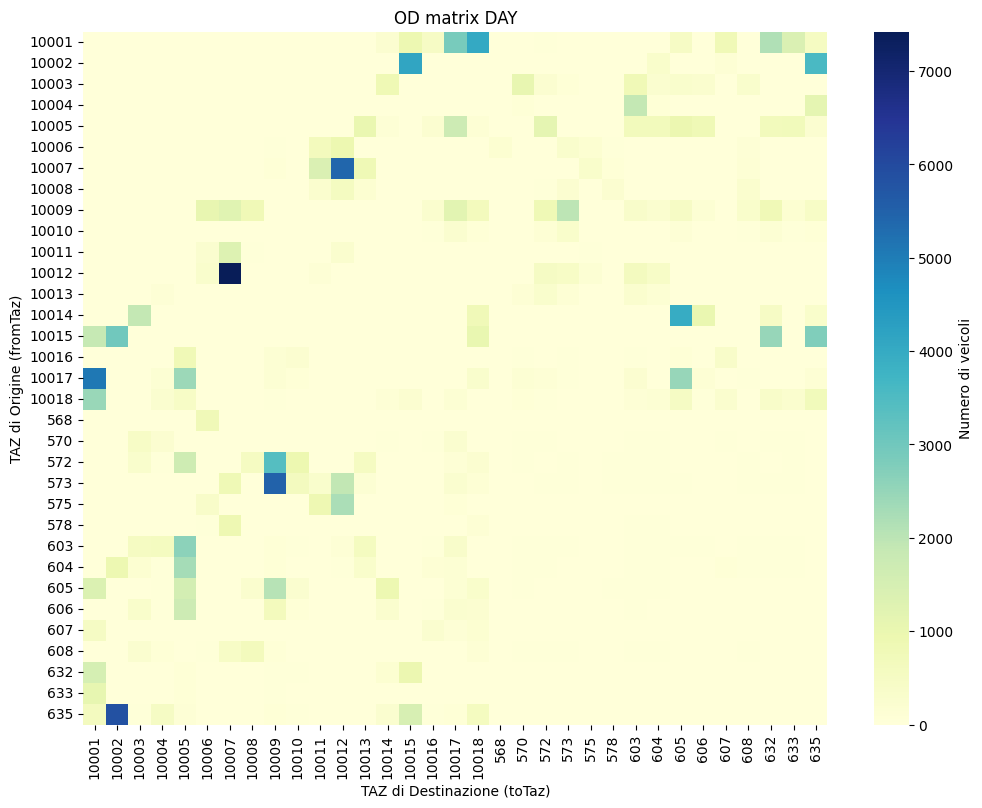

In [36]:
# Creiamo una tabella pivot con il conteggio dei veicoli tra zone
od_matrix = df_res.pivot_table(index='fromTaz', columns='toTaz', aggfunc='size', fill_value=0)

plt.figure(figsize=(12, 9))
sns.heatmap(od_matrix, annot=False, fmt="d", cmap="YlGnBu", cbar_kws={'label': 'Numero di veicoli'})
plt.title('OD matrix DAY')
plt.xlabel('TAZ di Destinazione (toTaz)')
plt.ylabel('TAZ di Origine (fromTaz)')
plt.show()